<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_2_LogisticRegression/18_2_3_LogReg_to_NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Logistic Regression
## From One Neuron to Many — The Bridge to Neural Networks

**Author:** Brad Sheese

---

## Introduction

In Notebook 18_2_1 we identified logistic regression as a single artificial neuron. In this notebook we follow that thread to its logical conclusion: what happens when you stack many neurons in layers? What problems can a single neuron not solve, and why does adding a hidden layer fix them? And what is the cost of that added power?

### Learning Objectives

1. Verify that logistic regression and a single-neuron network are mathematically identical.
2. Demonstrate the XOR problem — a simple task that logistic regression cannot solve but a two-layer network can.
3. Explain the role of hidden layers and activation functions in neural networks.
4. Build and interpret a shallow neural network with sklearn's `MLPClassifier`.
5. Understand what the 'neural' part of neural networks adds — and what it costs in terms of interpretability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import fetch_openml

np.random.seed(42)

---

## Section 1: Verifying That Logistic Regression Is a Single Neuron

We claimed in Notebook 18_2_1 that logistic regression is structurally identical to one artificial neuron. Let's verify this numerically: fit sklearn's `LogisticRegression`, then hand-compute the same output using the neuron formula, and confirm they match exactly.

In [2]:
# Load Titanic — same features as Notebooks 18_2_1 and 18_2_2
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_titanic.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.lower().str.replace(' aboard', '', regex=False)

df['sibspouse']   = (df['siblings/spouses'] > 0).astype(int)
df['parentchild'] = (df['parents/children'] > 0).astype(int)
df['sex_f']       = (df['sex'] == 'female').astype(int)
df['fare_log']    = np.log1p(df['fare'])
df = pd.get_dummies(df, columns=['pclass'], prefix='pclass', drop_first=True)
for col in ['pclass_2', 'pclass_3']:
    df[col] = df[col].astype(int)

features = ['age', 'sibspouse', 'parentchild', 'fare_log', 'sex_f', 'pclass_2', 'pclass_3']
X = df[features].values.astype(float)
y = df['survived'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_scaled, y)

# sklearn's predicted probability (the 'official' answer)
sklearn_proba = lr.predict_proba(X_scaled[:5])[:, 1]

# Hand-compute using the neuron formula: sigmoid(W·x + b)
W = lr.coef_[0]          # shape (7,) — one weight per feature
b = lr.intercept_[0]     # scalar bias

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

neuron_proba = sigmoid(X_scaled[:5] @ W + b)

print('First 5 passengers:')
print(f'  sklearn predict_proba : {sklearn_proba.round(6)}')
print(f'  neuron formula σ(Wx+b): {neuron_proba.round(6)}')
print(f'  Max absolute difference: {np.max(np.abs(sklearn_proba - neuron_proba)):.2e}')
print('\nThey are identical (within floating-point precision).')

First 5 passengers:
  sklearn predict_proba : [0.085685 0.903502 0.597625 0.908393 0.073888]
  neuron formula σ(Wx+b): [0.085685 0.903502 0.597625 0.908393 0.073888]
  Max absolute difference: 0.00e+00

They are identical (within floating-point precision).


The two computations agree to machine precision. Sklearn's `LogisticRegression.predict_proba` is doing exactly this:

$$\hat{p} = \sigma(\mathbf{W} \cdot \mathbf{x} + b) = \frac{1}{1+e^{-(w_1 x_1 + w_2 x_2 + \ldots + b)}}$$

This is one artificial neuron. The learning algorithm (gradient descent on cross-entropy loss) found the weights $\mathbf{W}$ and bias $b$ that best fit the data. A neural network does the same thing, but for *many* neurons.

---

## Section 2: The Problem Logistic Regression Cannot Solve

A single neuron can only draw a straight line (in 2D) or a hyperplane (in higher dimensions) as its decision boundary. This means it can only classify data that is *linearly separable* — where one class is on one side of a line and the other class is on the other side.

The **XOR problem** is the simplest dataset that is *not* linearly separable. It has four points, and no single straight line can correctly separate the two classes.

| x₁ | x₂ | Label |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Class 1 (the 1s) is in the top-left and bottom-right. No straight line can separate them from class 0 in the top-right and bottom-left.

Logistic Regression on XOR — Accuracy: 50%
Neural Network (1 hidden layer) on XOR — Accuracy: 100%


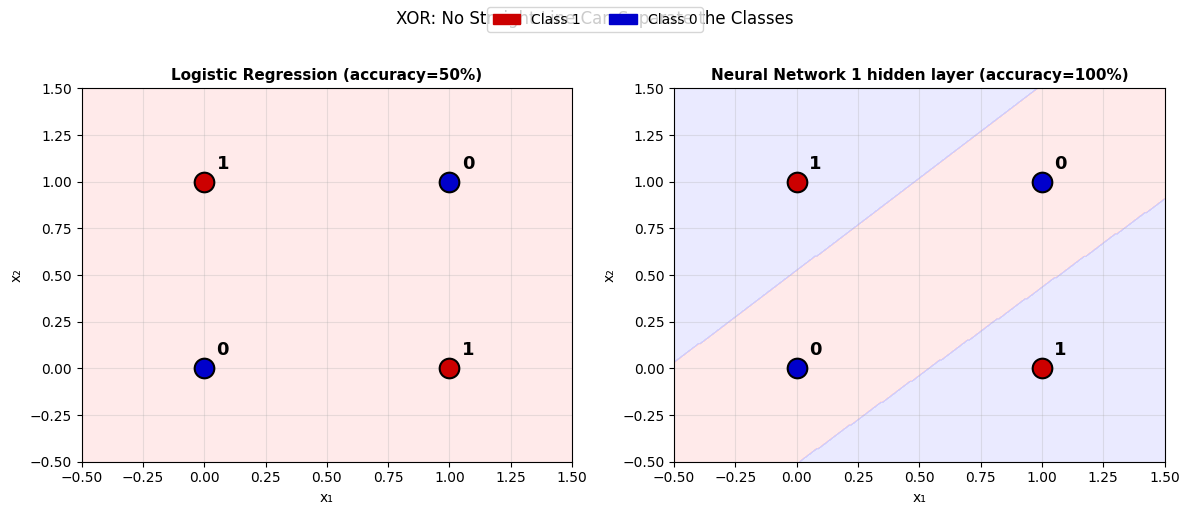

In [3]:
# XOR data
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# Fit logistic regression
lr_xor = LogisticRegression(random_state=42, max_iter=10000)
lr_xor.fit(X_xor, y_xor)
lr_acc = lr_xor.score(X_xor, y_xor)

# Fit a small neural network (one hidden layer with 4 neurons).
# On a 4-point dataset the lbfgs solver and tanh activation are far more
# reliable than the deep-learning defaults (adam + relu), which can get
# stuck in a flat region and never solve XOR.
mlp_xor = MLPClassifier(hidden_layer_sizes=(4,), activation='tanh', solver='lbfgs',
                        max_iter=10000, random_state=42)
mlp_xor.fit(X_xor, y_xor)
mlp_acc = mlp_xor.score(X_xor, y_xor)

print(f'Logistic Regression on XOR — Accuracy: {lr_acc:.0%}')
print(f'Neural Network (1 hidden layer) on XOR — Accuracy: {mlp_acc:.0%}')

# Visualize decision boundaries
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = [f'Logistic Regression (accuracy={lr_acc:.0%})',
          f'Neural Network 1 hidden layer (accuracy={mlp_acc:.0%})']
models = [lr_xor, mlp_xor]
cmap_bg = ListedColormap(['#ffcccc', '#ccccff'])

for ax, model, title in zip(axes, models, titles):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    for xi, yi, label in zip(X_xor[:,0], X_xor[:,1], y_xor):
        color = '#cc0000' if label == 1 else '#0000cc'
        ax.scatter(xi, yi, c=color, s=200, zorder=5, edgecolors='black', linewidths=1.5)
        ax.text(xi+0.05, yi+0.07, str(label), fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)

red_patch  = mpatches.Patch(color='#cc0000', label='Class 1')
blue_patch = mpatches.Patch(color='#0000cc', label='Class 0')
fig.legend(handles=[red_patch, blue_patch], loc='upper center', ncol=2, fontsize=10)
plt.suptitle('XOR: No Straight Line Can Separate the Classes', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### What Just Happened?

Logistic regression draws a straight line and gets 50% accuracy — no better than flipping a coin. The neural network draws a curved, non-linear boundary and solves XOR perfectly.

**Why can the neural network do this?** The hidden layer transforms the input space. The four hidden neurons each compute a different weighted combination of x₁ and x₂, passing them through an activation function. This creates a new, higher-dimensional representation of the data. In that new space, XOR *is* linearly separable.

The output neuron (which *is* a logistic regression) then draws a straight line in that transformed space — which corresponds to a curved boundary in the original space.

**This is the key insight**: a neural network is logistic regression applied to learned transformations of the input, stacked in layers.

---

## Section 3: From One Neuron to a Network

### The Architecture

A neural network is a directed graph of neurons organized in layers:

- **Input layer**: the raw features (one node per feature)
- **Hidden layer(s)**: one or more layers of neurons, each receiving inputs from the previous layer, applying weights + bias + activation
- **Output layer**: one neuron per class (sigmoid for binary, softmax for multiclass)

Each connection between layers is a weight. Training a neural network means finding the values of *all* those weights simultaneously using gradient descent — the same algorithm logistic regression uses, but applied to millions of parameters at once.

### Activation Functions

In Notebook 18_2_1 we used the sigmoid as our activation function. Modern neural networks rarely use sigmoid in hidden layers — they use **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(z) = \max(0, z)$$

ReLU is simpler, faster, and avoids the 'vanishing gradient' problem that plagues deep sigmoid networks. But for the *output layer* of a binary classifier, sigmoid is still standard — it maps the final logit to a probability in [0, 1].

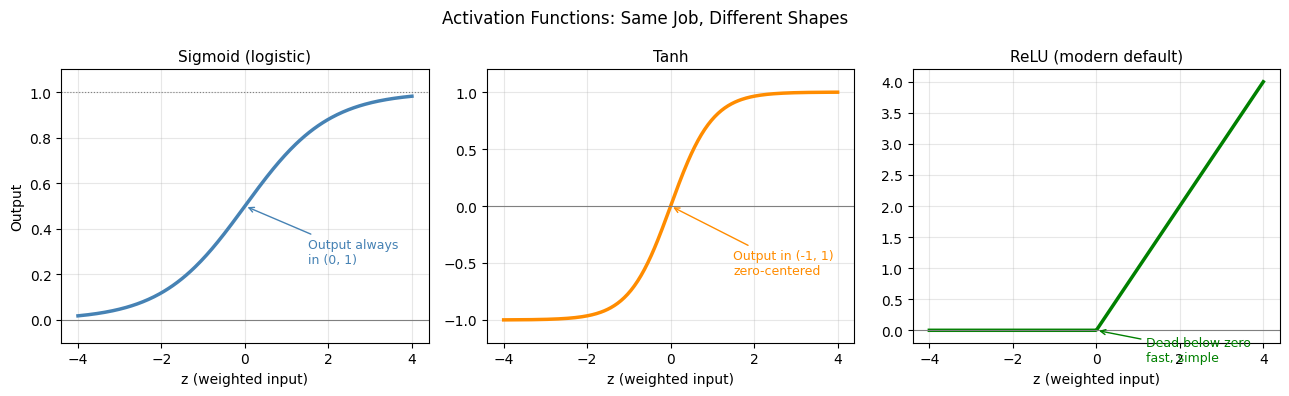

Sigmoid → used at the output layer of binary classifiers (produces probabilities)
ReLU    → used in hidden layers of modern deep networks (avoids vanishing gradients)


In [4]:
z = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Sigmoid
axes[0].plot(z, 1 / (1 + np.exp(-z)), 'steelblue', lw=2.5)
axes[0].set_title('Sigmoid (logistic)', fontsize=11)
axes[0].set_ylabel('Output')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].axhline(1, color='gray', lw=0.8, linestyle=':')
axes[0].set_ylim(-0.1, 1.1)
axes[0].annotate('Output always\nin (0, 1)', xy=(0, 0.5), xytext=(1.5, 0.25),
                 fontsize=9, color='steelblue',
                 arrowprops=dict(arrowstyle='->', color='steelblue'))

# Tanh
axes[1].plot(z, np.tanh(z), 'darkorange', lw=2.5)
axes[1].set_title('Tanh', fontsize=11)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylim(-1.2, 1.2)
axes[1].annotate('Output in (-1, 1)\nzero-centered', xy=(0, 0), xytext=(1.5, -0.6),
                 fontsize=9, color='darkorange',
                 arrowprops=dict(arrowstyle='->', color='darkorange'))

# ReLU
axes[2].plot(z, np.maximum(0, z), 'green', lw=2.5)
axes[2].set_title('ReLU (modern default)', fontsize=11)
axes[2].axhline(0, color='gray', lw=0.8)
axes[2].annotate('Dead below zero\nfast, simple', xy=(0, 0), xytext=(1.2, -0.5),
                 fontsize=9, color='green',
                 arrowprops=dict(arrowstyle='->', color='green'))

for ax in axes:
    ax.set_xlabel('z (weighted input)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions: Same Job, Different Shapes', fontsize=12)
plt.tight_layout()
plt.show()

print('Sigmoid → used at the output layer of binary classifiers (produces probabilities)')
print('ReLU    → used in hidden layers of modern deep networks (avoids vanishing gradients)')

---

## Section 4: A Neural Network on Titanic

Let's build a small neural network on the Titanic data and compare it to our logistic regression model. We use sklearn's `MLPClassifier` — MLP stands for *Multi-Layer Perceptron*, which is the classical term for a fully-connected neural network.

We will try two architectures:
- **Shallow**: one hidden layer with 16 neurons
- **Deeper**: two hidden layers (16, 8 neurons)

Both use ReLU in hidden layers and sigmoid at the output (standard for binary classification).

In [5]:
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_titanic.csv'
df = pd.read_csv(url)
df.columns = df.columns.str.lower().str.replace(' aboard', '', regex=False)
df['sibspouse']   = (df['siblings/spouses'] > 0).astype(int)
df['parentchild'] = (df['parents/children'] > 0).astype(int)
df['sex_f']       = (df['sex'] == 'female').astype(int)
df['fare_log']    = np.log1p(df['fare'])
df = pd.get_dummies(df, columns=['pclass'], prefix='pclass', drop_first=True)
for col in ['pclass_2', 'pclass_3']:
    df[col] = df[col].astype(int)

features = ['age', 'sibspouse', 'parentchild', 'fare_log', 'sex_f', 'pclass_2', 'pclass_3']
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

numeric_features = ['age', 'fare_log']
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'
)

# Logistic Regression (baseline)
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Shallow MLP: 1 hidden layer
mlp_shallow = Pipeline([
    ('pre', preprocessor),
    ('clf', MLPClassifier(hidden_layer_sizes=(16,), activation='relu',
                          max_iter=1000, random_state=42))
])

# Deeper MLP: 2 hidden layers
mlp_deep = Pipeline([
    ('pre', preprocessor),
    ('clf', MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu',
                          max_iter=1000, random_state=42))
])

results = {}
for name, model in [('Logistic Regression', lr_pipe),
                     ('MLP (16,)', mlp_shallow),
                     ('MLP (16,8)', mlp_deep)]:
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results[name] = acc
    print(f'{name:<25} Accuracy: {acc:.3f}')

Logistic Regression       Accuracy: 0.770


MLP (16,)                 Accuracy: 0.793


MLP (16,8)                Accuracy: 0.797


### What the Numbers Say

All three models perform similarly on the Titanic test set. This is not surprising: the dominant signals (sex, passenger class, age) are all captured by a linear boundary. The neural network's ability to model non-linear interactions is simply not needed here.

This is an important calibration: **more complex models do not always win**. On a small dataset with linear structure, logistic regression is competitive with a neural network — and far more interpretable.

The neural network becomes the better choice when:
- The dataset is large (tens of thousands of samples or more)
- The features have complex non-linear interactions the model must discover
- You are working with raw inputs (images, text, audio) where handcrafted features are impractical

---

## Section 5: What the Neural Network Loses

Logistic regression's weights are directly interpretable — we can read off the effect of each feature on the log-odds. What about the neural network's weights?

Let's look at the weights of the shallow MLP.

In [6]:
mlp_clf = mlp_shallow.named_steps['clf']

print('MLP Architecture')
print(f'  Input features: {len(features)}')
print(f'  Hidden layer 1: {mlp_clf.hidden_layer_sizes[0]} neurons')
print(f'  Output layer:   1 neuron (sigmoid)')
print()
print('Weight matrix shapes:')
for i, (W, b) in enumerate(zip(mlp_clf.coefs_, mlp_clf.intercepts_)):
    print(f'  Layer {i+1}: W shape {W.shape}, bias shape {b.shape}')
print()
print(f'Total trainable parameters: '
      f'{sum(W.size for W in mlp_clf.coefs_) + sum(b.size for b in mlp_clf.intercepts_)}')
print()
W1 = mlp_clf.coefs_[0]
print('First 3 rows of the hidden layer weight matrix (input→hidden):')
print('(Each column is one hidden neuron; each row is one input feature)')
print(pd.DataFrame(W1, index=features).round(3).iloc[:, :6].to_string())
print('\nCan you interpret what hidden neuron 1 is doing? No — the weights are opaque.')

MLP Architecture
  Input features: 7
  Hidden layer 1: 16 neurons
  Output layer:   1 neuron (sigmoid)

Weight matrix shapes:
  Layer 1: W shape (7, 16), bias shape (16,)
  Layer 2: W shape (16, 1), bias shape (1,)

Total trainable parameters: 145

First 3 rows of the hidden layer weight matrix (input→hidden):
(Each column is one hidden neuron; each row is one input feature)
                 0      1      2      3      4      5
age          0.120  0.423  0.551  0.262 -0.392 -0.175
sibspouse    0.064  0.184  0.369 -0.274  0.380 -0.119
parentchild -0.351  0.882  0.782  0.566 -0.073  0.169
fare_log    -0.212  0.225  0.972  0.418  0.475  0.420
sex_f       -0.569 -0.090 -0.390  0.217 -0.625  0.722
pclass_2     0.595  0.619  0.112 -0.586  0.174 -0.604
pclass_3    -0.163  0.385 -0.224 -0.000 -0.072  0.537

Can you interpret what hidden neuron 1 is doing? No — the weights are opaque.


### The Interpretability Tax

The hidden layer weight matrix has `7 features × 16 neurons = 112 weights`. None of them have a clean interpretation. Unlike a logistic regression coefficient, you cannot look at the weight connecting 'sex' to hidden neuron 3 and say anything meaningful about what the model has learned.

This is the **interpretability tax** of neural networks: they gain expressive power by learning transformations of the input, but those transformations are distributed across all the weights and have no human-readable meaning.

| Model | Parameters | Interpretable? | Max expressiveness |
|---|---|---|---|
| Logistic Regression | 8 (7 + bias) | Yes — odds ratios | Linear boundaries only |
| MLP (16,) | 145 | No | Any continuous function* |
| MLP (16, 8) | 281 | No | Any continuous function* |

*Given enough neurons — the Universal Approximation Theorem

The right model for any problem depends on which side of this trade-off matters more: interpretability or raw expressive power.

---

## Summary

In this notebook you:

1. **Verified numerically** that logistic regression and a single artificial neuron are identical: $\hat{p} = \sigma(\mathbf{W}\cdot\mathbf{x} + b)$.
2. Demonstrated the **XOR problem**: a simple dataset that is not linearly separable and that logistic regression cannot solve, but a network with one hidden layer can.
3. Explained **why hidden layers work**: they transform the input into a new space where the data becomes linearly separable, then the output neuron draws a straight line.
4. Compared **activation functions**: sigmoid (probabilistic output, hidden layers in old networks), tanh (zero-centered), ReLU (modern default for hidden layers).
5. Built a shallow MLP on Titanic and confirmed that the neural network does not meaningfully outperform logistic regression — a couple of accuracy points on a 222-passenger test set is within noise, and the data's linear structure means added complexity buys little.
6. Examined the **interpretability tax**: neural network weights are opaque because they encode learned transformations, not direct feature effects.

### The Three-Part Summary of This Module

| Notebook | Core lesson |
|---|---|
| 18_2_1: Foundations | LR = sigmoid(linear combination) = one neuron |
| 18_2_2: Interpretability | LR explains *direction + magnitude + uncertainty*; XGBoost cannot |
| 18_2_3: NN Connection | Adding layers = learned transformations; gained power costs interpretability |

**What comes next:** Module 18_5 (Multi-Class Classification) and eventually a dedicated neural networks module that will build directly on the vocabulary established here: neurons, layers, activations, weights, biases, gradient descent, and cross-entropy loss.

---

## Problems

### Problem 1: The Neuron Formula
A logistic regression model has been fit with:
- Intercept (bias): −1.2
- Weight for feature x₁: 0.8
- Weight for feature x₂: −1.5

For a new data point with x₁ = 2.0 and x₂ = 1.0, compute the predicted probability by hand. Show your steps: (1) compute z, (2) compute σ(z).

*Write your answer here.*

### Problem 2: Why XOR Fails for Logistic Regression
Explain in your own words why no single straight line can separate the XOR classes. Draw a rough sketch (on paper or in words) showing why the points are not linearly separable.

*Write your answer here.*

### Problem 3: Activation Function Choice
A colleague says: 'We should use sigmoid activations in all hidden layers because we want the outputs to be probabilities.' What is wrong with this reasoning? What problem does ReLU solve that sigmoid does not?

*Write your answer here.*

### Problem 4: When Do You Need the Extra Power?
The Titanic MLP performed similarly to logistic regression. Name a classification problem from a domain you know where you would expect a neural network to significantly outperform logistic regression. Explain what property of that problem requires the added expressiveness.

*Write your answer here.*